In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

In [2]:
df = pd.read_csv('../data/vehicles.csv')

In [3]:
df.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


In [7]:
df.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,4345,4173.000000,4345,4345.000000,4195.000000,4345,4345,4345.000000,4345
unique,7,NaN,6,NaN,NaN,4,2,NaN,312
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,E-Class
freq,936,NaN,1649,NaN,NaN,2019,3947,NaN,199
mean,NaN,19418.746935,NaN,161.237284,2.790734,NaN,NaN,2006.550058,NaN
std,NaN,25584.242620,NaN,105.705797,5.066437,NaN,NaN,6.719097,NaN
min,NaN,600.000000,NaN,0.000000,0.600000,NaN,NaN,1969.000000,NaN
25%,NaN,6999.000000,NaN,86.000000,1.800000,NaN,NaN,2003.000000,NaN
50%,NaN,11500.000000,NaN,155.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,21700.000000,NaN,230.000000,3.000000,NaN,NaN,2012.000000,NaN


In [8]:
df["Body"].unique()

array(['sedan', 'van', 'crossover', 'vagon', 'other', 'hatch'],
      dtype=object)

In [9]:
df["Brand"].unique()

array(['BMW', 'Mercedes-Benz', 'Audi', 'Toyota', 'Renault', 'Volkswagen',
       'Mitsubishi'], dtype=object)

In [14]:
df["Engine Type"].unique()

array(['Petrol', 'Diesel', 'Gas', 'Other'], dtype=object)

In [18]:
df.isnull().sum()*100/len(df)

Brand           0.000000
Price           3.958573
Body            0.000000
Mileage         0.000000
EngineV         3.452244
Engine Type     0.000000
Registration    0.000000
Year            0.000000
Model           0.000000
dtype: float64

In [20]:
# remove null values
df.dropna(axis=0, inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4025 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4025 non-null   object 
 1   Price         4025 non-null   float64
 2   Body          4025 non-null   object 
 3   Mileage       4025 non-null   int64  
 4   EngineV       4025 non-null   float64
 5   Engine Type   4025 non-null   object 
 6   Registration  4025 non-null   object 
 7   Year          4025 non-null   int64  
 8   Model         4025 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 314.5+ KB


In [25]:
df[['Price', 'Mileage', 'EngineV']].describe(include='all')

,Price,Mileage,EngineV
count,4025.000000,4025.000000,4025.000000
mean,19552.308065,163.572174,2.764586
std,25815.734988,103.394703,4.935941
min,600.000000,0.000000,0.600000
25%,6999.000000,90.000000,1.800000
50%,11500.000000,158.000000,2.200000
75%,21900.000000,230.000000,3.000000
max,300000.000000,980.000000,99.990000


/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_1119/2094104316.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df['Price'], labels=['Price'])


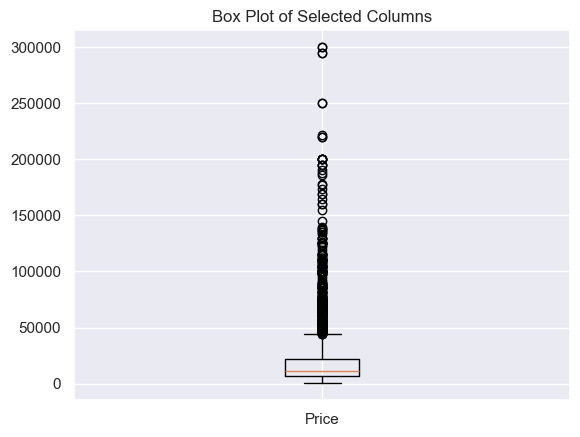

In [29]:
plt.boxplot(df['Price'], labels=['Price'])
plt.title('Box Plot of Selected Columns')

plt.show()

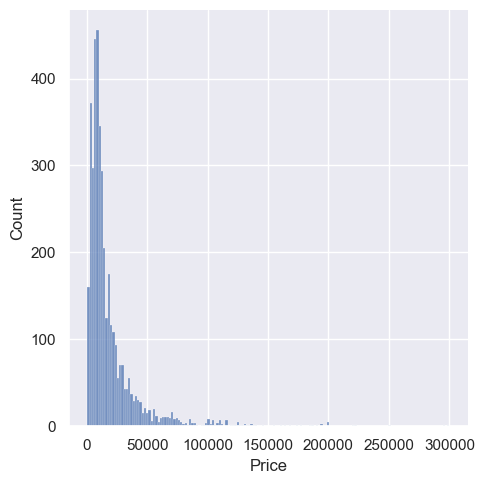

In [22]:
sns.displot(df['Price'])

In [41]:
# top 2% data
top2P = df['Price'].quantile(0.98)
top2P_data = df[df['Price']>=top2P]
print(len(top2P_data))
top2P_data.head()

82


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
5,Mercedes-Benz,199999.0,crossover,0,5.50,Petrol,yes,2016,GLS 63
62,BMW,133000.0,crossover,7,4.40,Petrol,yes,2015,X5 M
104,Mercedes-Benz,107999.0,crossover,0,2.98,Diesel,yes,2016,GLS 350
131,Toyota,195000.0,crossover,0,4.50,Diesel,yes,2016,Land Cruiser 200
173,Mercedes-Benz,169000.0,other,1,4.70,Petrol,yes,2015,S 500


In [35]:
q98_data = df[df['Price']<top2P]
print(len(q98_data))
q98_data.head()

3943


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_1119/2376116924.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(q98_data['Price'], labels=['Price'])


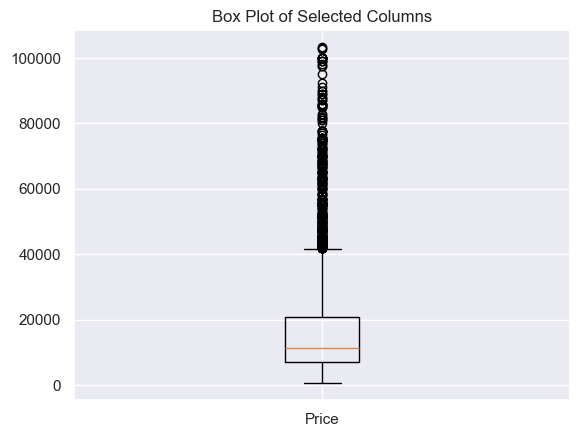

In [36]:
plt.boxplot(q98_data['Price'], labels=['Price'])
plt.title('Box Plot of Selected Columns')

plt.show()

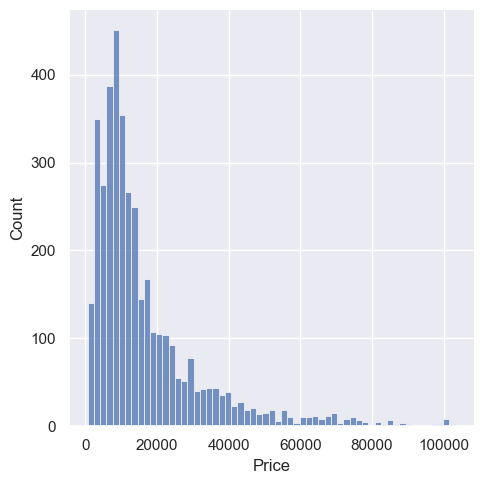

In [37]:
sns.displot(q98_data['Price'])

/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_1119/2212052302.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(q98_data['Mileage'], labels=['Price'])


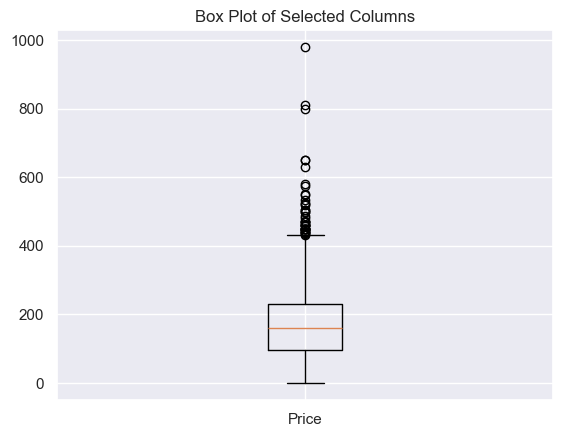

In [40]:
plt.boxplot(q98_data['Mileage'], labels=['Mileage'])
plt.title('Box Plot of Selected Columns')

plt.show()

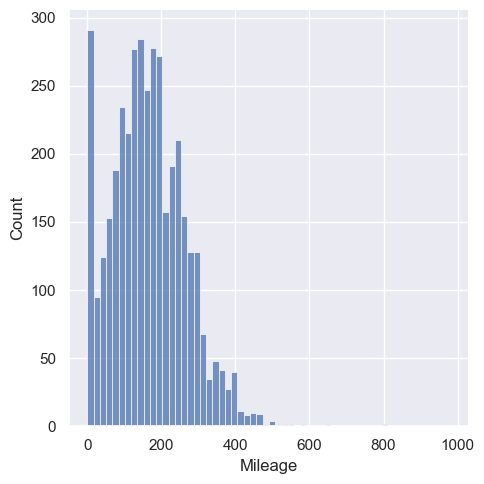

In [38]:
sns.displot(q98_data['Mileage'])

In [42]:
# top 2% data
top2PM = q98_data['Mileage'].quantile(0.98)
top2P_data = q98_data[q98_data['Mileage']>=top2PM]
print(len(top2P_data))
top2P_data.head()

88


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
6,BMW,6100.0,sedan,438,2.0,Gas,yes,1997,320
78,Audi,3700.0,hatch,420,2.0,Diesel,no,2004,A3
95,Mercedes-Benz,4000.0,sedan,405,2.0,Diesel,yes,1992,200
258,Volkswagen,2500.0,sedan,488,2.0,Petrol,yes,1991,Passat B3


In [43]:
q98_data = q98_data[q98_data['Mileage']<top2PM]
print(len(q98_data))
q98_data.head()

3855


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4
7,Audi,14200.0,vagon,200,2.7,Diesel,yes,2006,A6


/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_1119/3961352727.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(q98_data['Mileage'], labels=['Mileage'])


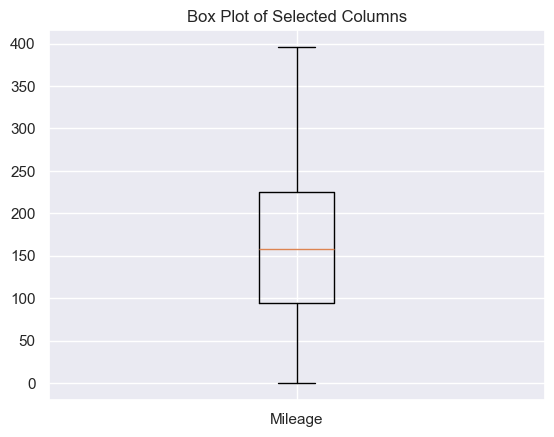

In [44]:
plt.boxplot(q98_data['Mileage'], labels=['Mileage'])
plt.title('Box Plot of Selected Columns')

plt.show()

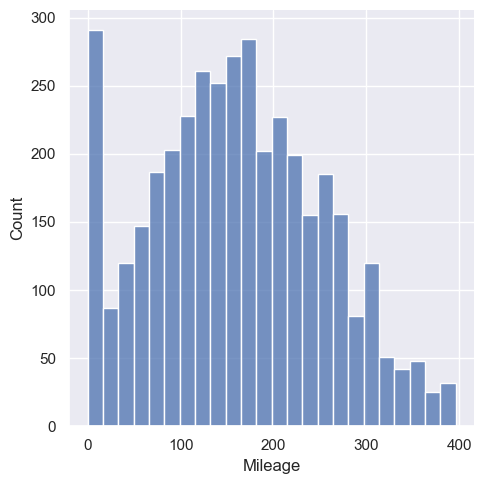

In [45]:
sns.displot(q98_data['Mileage'])

/var/folders/qj/csh4ys_506qc4hr_myvhtfym0000gn/T/ipykernel_1119/425011826.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(q98_data['EngineV'], labels=['EngineV'])


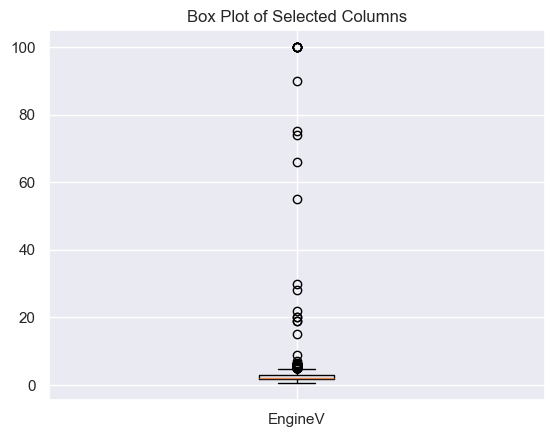

In [46]:
plt.boxplot(q98_data['EngineV'], labels=['EngineV'])
plt.title('Box Plot of Selected Columns')

plt.show()

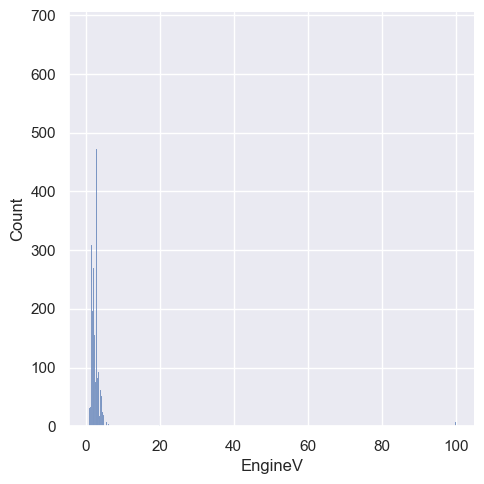

In [47]:
sns.displot(q98_data['EngineV'])

In [48]:
engine = q98_data[q98_data['EngineV']>=6.5]
print(len(engine))

23


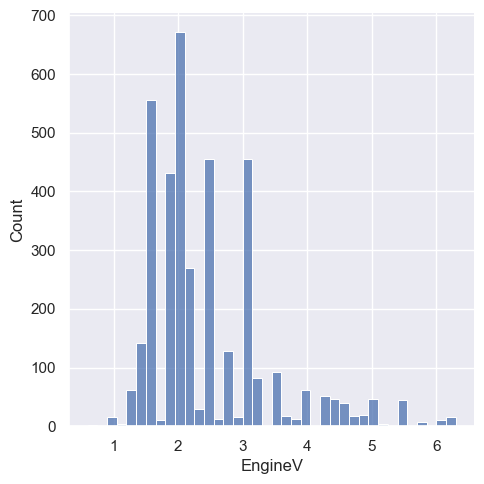

In [50]:
q98_data = q98_data[q98_data['EngineV']<6.5]
sns.displot(q98_data['EngineV'])

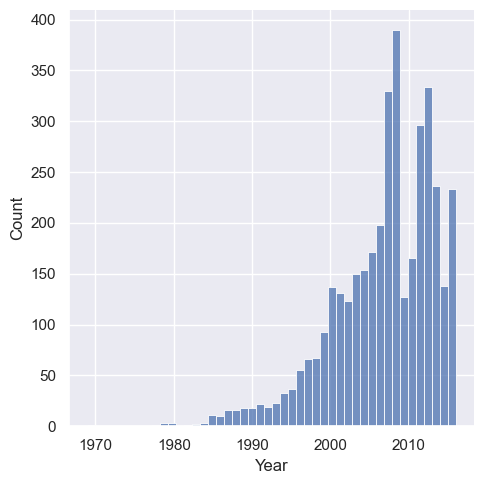

In [51]:
sns.displot(q98_data['Year'])

In [55]:
old_veh=q98_data[q98_data['Year']<2000]
print(len(q98_data),len(old_veh))
old_veh

3832 518


,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.00,Petrol,yes,1991,320
9,Volkswagen,1400.0,other,212,1.80,Gas,no,1999,Golf IV
11,Renault,2500.0,sedan,260,1.79,Petrol,yes,1994,19
19,Audi,3500.0,vagon,250,2.50,Diesel,no,1998,A6
22,Audi,6800.0,sedan,225,2.40,Gas,yes,1998,A6
...,...,...,...,...,...,...,...,...,...
4294,Mitsubishi,3250.0,sedan,380,1.80,Petrol,yes,1993,Galant
4300,Audi,4850.0,sedan,270,2.60,Petrol,yes,1995,A6
4325,Mercedes-Benz,8200.0,sedan,280,2.40,Gas,yes,1997,E-Class
4341,BMW,6500.0,sedan,1,3.50,Petrol,yes,1999,535


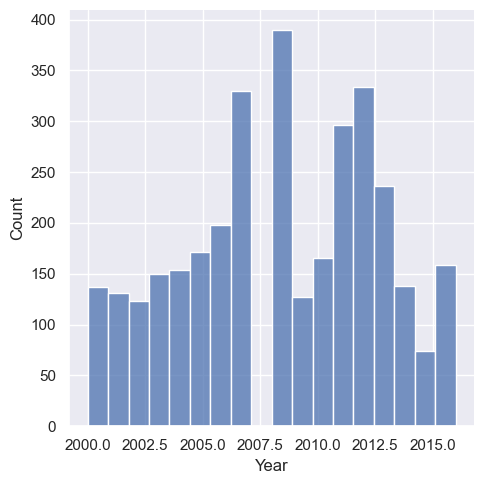

In [56]:
q98_data=q98_data[q98_data['Year']>=2000]
sns.displot(q98_data['Year'])

In [57]:
data_cleaned =  q98_data.reset_index(drop=True)

In [58]:
data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
count,3314,3314.000000,3314,3314.000000,3314.000000,3314,3314,3314.000000,3314
unique,7,NaN,6,NaN,NaN,4,2,NaN,256
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,NaN,Vito
freq,743,NaN,1152,NaN,NaN,1606,3071,NaN,141
mean,NaN,19098.218123,NaN,146.245323,2.456473,NaN,NaN,2008.339469,NaN
std,NaN,16773.017599,NaN,83.485759,0.979413,NaN,NaN,4.311207,NaN
min,NaN,1200.000000,NaN,0.000000,0.600000,NaN,NaN,2000.000000,NaN
25%,NaN,8650.000000,NaN,86.250000,1.800000,NaN,NaN,2005.000000,NaN
50%,NaN,12950.000000,NaN,146.000000,2.200000,NaN,NaN,2008.000000,NaN
75%,NaN,23400.000000,NaN,200.000000,3.000000,NaN,NaN,2012.000000,NaN


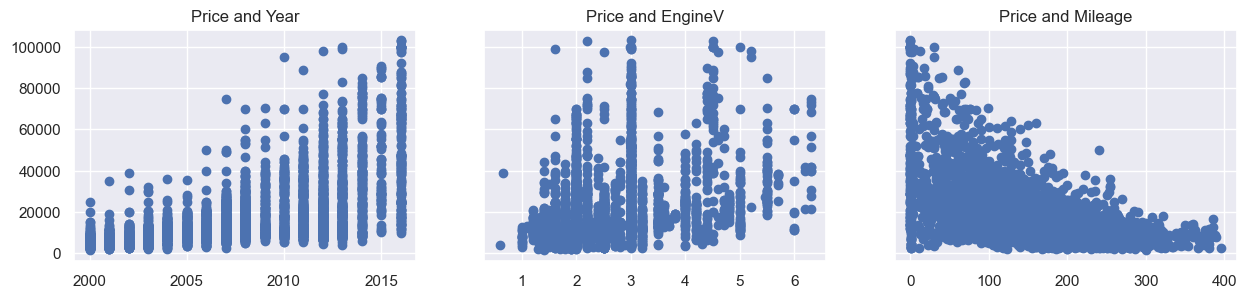

In [61]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize =(15,3)) #sharey -> share 'Price' as y
ax1.scatter(data_cleaned['Year'],data_cleaned['Price'])
ax1.set_title('Price and Year')
ax2.scatter(data_cleaned['EngineV'],data_cleaned['Price'])
ax2.set_title('Price and EngineV')
ax3.scatter(data_cleaned['Mileage'],data_cleaned['Price'])
ax3.set_title('Price and Mileage')
plt.show()

In [63]:
# Let's transform 'Price' with a log transformation
log_price = np.log(data_cleaned['Price'])

# Then we add it to our data frame
data_cleaned['log_price'] = log_price

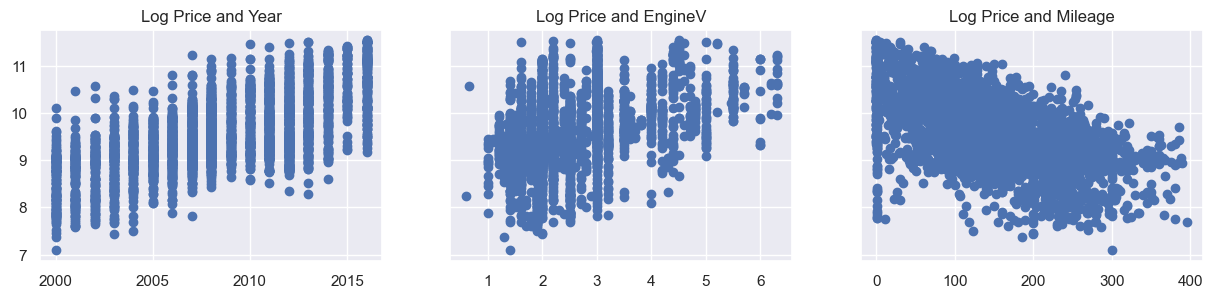

In [64]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize =(15,3))
ax1.scatter(data_cleaned['Year'],data_cleaned['log_price'])
ax1.set_title('Log Price and Year')
ax2.scatter(data_cleaned['EngineV'],data_cleaned['log_price'])
ax2.set_title('Log Price and EngineV')
ax3.scatter(data_cleaned['Mileage'],data_cleaned['log_price'])
ax3.set_title('Log Price and Mileage')
plt.show()

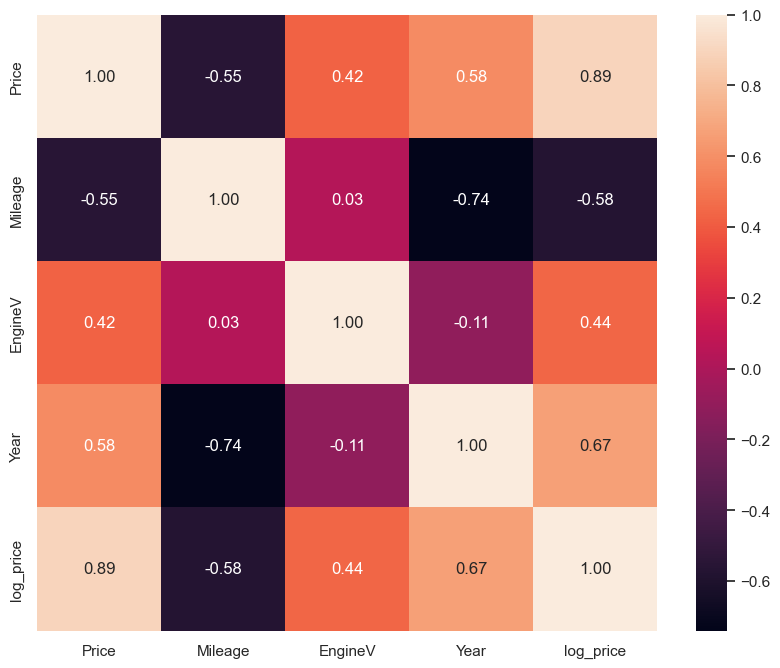

In [65]:
corr = data_cleaned.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

	# +1 or -1 → strong correlation

In [69]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data_cleaned[['Mileage','Year','EngineV']]  # features only (no target ideally)

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

# 🔥 Interpretation:
    # VIF=1/1-r*2
# 	•	VIF = 1 → no correlation
# 	•	VIF > 5 → moderate problem
# 	•	VIF > 10 → serious multicollinearity

   feature        VIF
0  Mileage   4.053039
1     Year  10.004446
2  EngineV   7.294433


In [70]:
data_cleaned = data_cleaned.drop(['Year'],axis=1)

In [72]:
data_cleaned.describe(include='all')

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Model,log_price
count,3314,3314.000000,3314,3314.000000,3314.000000,3314,3314,3314,3314.000000
unique,7,NaN,6,NaN,NaN,4,2,256,NaN
top,Volkswagen,NaN,sedan,NaN,NaN,Diesel,yes,Vito,NaN
freq,743,NaN,1152,NaN,NaN,1606,3071,141,NaN
mean,NaN,19098.218123,NaN,146.245323,2.456473,NaN,NaN,NaN,9.559670
std,NaN,16773.017599,NaN,83.485759,0.979413,NaN,NaN,NaN,0.760758
min,NaN,1200.000000,NaN,0.000000,0.600000,NaN,NaN,NaN,7.090077
25%,NaN,8650.000000,NaN,86.250000,1.800000,NaN,NaN,NaN,9.065315
50%,NaN,12950.000000,NaN,146.000000,2.200000,NaN,NaN,NaN,9.468851
75%,NaN,23400.000000,NaN,200.000000,3.000000,NaN,NaN,NaN,10.060491


In [ ]:
data_cleaned = data_cleaned.drop(['Model','Price'],axis=1)

In [76]:
data_cleaned =pd.get_dummies(data_cleaned, drop_first=True)

In [79]:
data_cleaned.columns.values

array(['Mileage', 'EngineV', 'log_price', 'Brand_BMW',
       'Brand_Mercedes-Benz', 'Brand_Mitsubishi', 'Brand_Renault',
       'Brand_Toyota', 'Brand_Volkswagen', 'Body_hatch', 'Body_other',
       'Body_sedan', 'Body_vagon', 'Body_van', 'Engine Type_Gas',
       'Engine Type_Other', 'Engine Type_Petrol', 'Registration_yes'],
      dtype=object)

In [80]:
targets = data_cleaned['log_price']
inputs = data_cleaned.drop(['log_price'],axis=1)

In [ ]:
# Import the scaling module
from sklearn.preprocessing import StandardScaler

# Create a scaler object
scaler = StandardScaler()
# Fit the inputs (calculate the mean and standard deviation feature-wise)
scaler.fit(inputs)

# Scale the features and store them in a new variable (the actual scaling procedure)
inputs_scaled = scaler.transform(inputs)

In [82]:
inputs_scaled

array([[ 2.53679953,  2.59738315, -0.41405153, ..., -0.16224654,
        -0.7426292 ,  0.28129579],
       [ 1.12317151,  1.78044425, -0.41405153, ..., -0.16224654,
         1.34656704,  0.28129579],
       [-0.3144163 , -0.46613772, -0.41405153, ..., -0.16224654,
         1.34656704,  0.28129579],
       ...,
       [ 0.20071933,  0.04444909, -0.41405153, ..., -0.16224654,
        -0.7426292 ,  0.28129579],
       [-1.33270767, -0.87460717, -0.41405153, ..., -0.16224654,
         1.34656704,  0.28129579],
       [-0.26649671, -0.46613772, -0.41405153, ..., -0.16224654,
        -0.7426292 ,  0.28129579]], shape=(3314, 17))

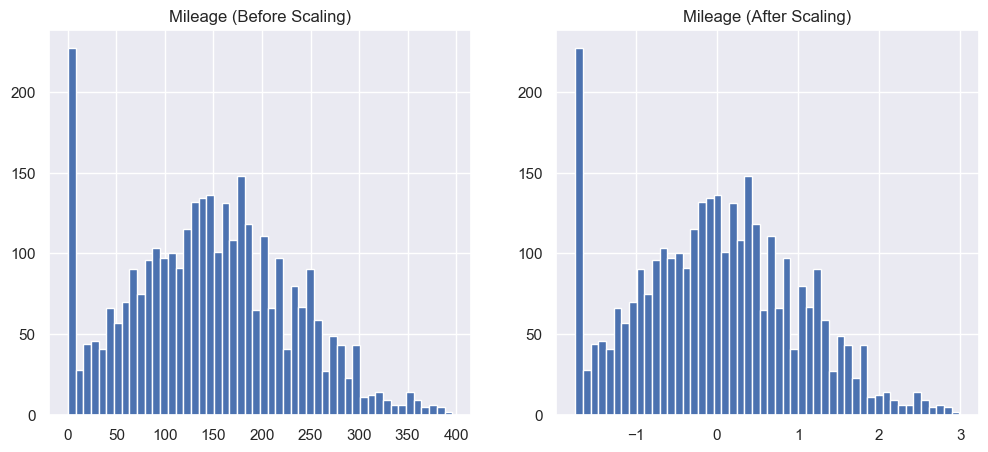

In [83]:
# Before scaling
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(inputs['Mileage'], bins=50)
plt.title('Mileage (Before Scaling)')

# After scaling
plt.subplot(1,2,2)
plt.hist(inputs_scaled[:, inputs.columns.get_loc('Mileage')], bins=50)
plt.title('Mileage (After Scaling)')

plt.show()

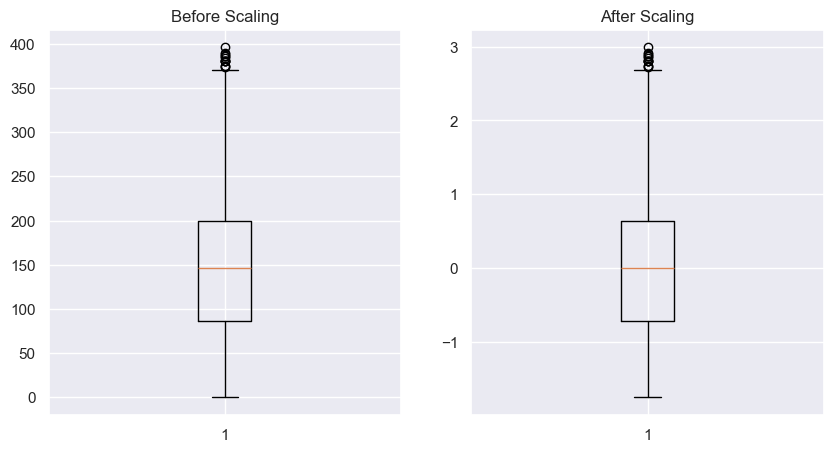

In [84]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(inputs['Mileage'])
plt.title('Before Scaling')

plt.subplot(1,2,2)
plt.boxplot(inputs_scaled[:, inputs.columns.get_loc('Mileage')])
plt.title('After Scaling')

plt.show()

In [85]:
# Import the module for the split
from sklearn.model_selection import train_test_split

# Spliting the variables with an 80-20 split and some random state
# random state(with any integer), makes the split same everytime we run the code. without it, we get different 
# splits every time we run the code. so You are not removing randomness — you are controlling it
x_train, x_test, y_train, y_test = train_test_split(inputs_scaled, targets, test_size=0.2, random_state=365)

In [86]:
# Create a linear regression object
reg = LinearRegression()
# Fit the regression with the scaled TRAIN inputs and targets
reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [87]:
# Checking the outputs of the regression
y_hat = reg.predict(x_train)

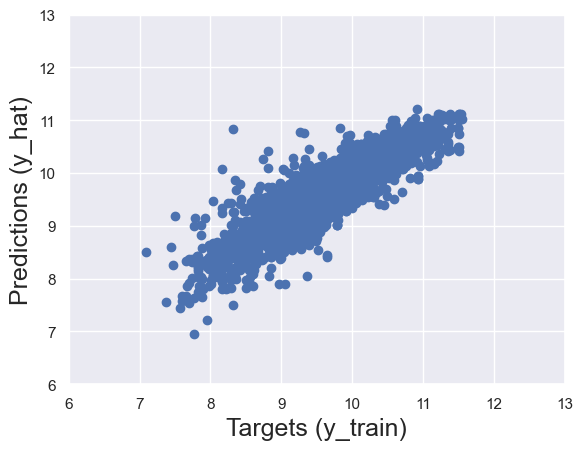

In [88]:
# Comparing the targets (y_train) and the predictions (y_hat)
plt.scatter(y_train, y_hat)
plt.xlabel('Targets (y_train)',size=18)
plt.ylabel('Predictions (y_hat)',size=18)
plt.xlim(6,13)
plt.ylim(6,13)
plt.show()

Observing the plot, it’s evident that Predictions and Targets align along the 45-degree line. This alignment signifies a close match between the regression predictions and the actual target values.

In [91]:
# Distrubtion of Residuals

In [92]:
y_train

59       8.817298
2037     9.769956
169      9.220291
1224     9.546813
2107     9.174713
          ...    
2309     9.159047
428      9.047821
859      9.104980
801      9.071078
2740    10.621327
Name: log_price, Length: 2651, dtype: float64

In [89]:
y_hat

array([ 8.76311654, 10.01902768,  9.48684792, ...,  9.00879799,
        8.74693818, 10.34035778], shape=(2651,))

In [95]:
res=y_train - y_hat
res

# 🔍 What residuals mean

# For each data point:
# 	•	Positive residual
            # → actual > predicted
            # → model underestimated
# 	•	Negative residual
            # → predicted > actual
            # → model overestimated

59      0.054181
2037   -0.249072
169    -0.266557
1224    0.257307
2107    0.246165
          ...   
2309   -0.371958
428    -0.109119
859     0.096182
801     0.324140
2740    0.280970
Name: log_price, Length: 2651, dtype: float64

Text(0.5, 1.0, 'Residuals PDF')

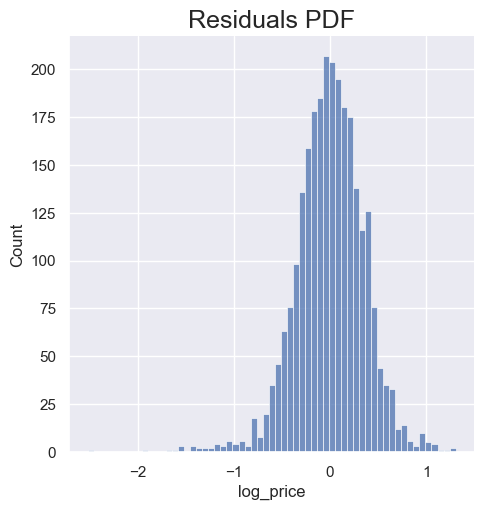

In [94]:
sns.displot(y_train - y_hat)

plt.title("Residuals PDF", size=18)

In [97]:
score =reg.score(x_train,y_train)
intercept =reg.intercept_
coefficents =reg.coef_
print("Score: ",score)
print("Intercept: ",intercept)
print("Coefficents: ",coefficents)

# Score is the r squared
# intercept is the y value when all x is 0
# since we scaled the data, “How much y changes for a 1 standard deviation increase in the feature”

Score:  0.7729802694208976
Intercept:  9.552390995644286
Coefficents:  [-0.38443179  0.20226738  0.01884949 -0.01068587 -0.16007614 -0.2091193
 -0.08277    -0.10122386 -0.12897984 -0.09415697 -0.15191865 -0.10554317
 -0.16310756 -0.09165309 -0.02494355 -0.13813714  0.27699499]


In [98]:
reg_summary = pd.DataFrame(inputs.columns.values, columns=['Features'])
reg_summary['Weights'] = reg.coef_
reg_summary

,Features,Weights
0,Mileage,-0.384432
1,EngineV,0.202267
2,Brand_BMW,0.018849
3,Brand_Mercedes-Benz,-0.010686
4,Brand_Mitsubishi,-0.160076
5,Brand_Renault,-0.209119
6,Brand_Toyota,-0.082770
7,Brand_Volkswagen,-0.101224
8,Body_hatch,-0.128980
9,Body_other,-0.094157


In [99]:
y_hat_test = reg.predict(x_test)

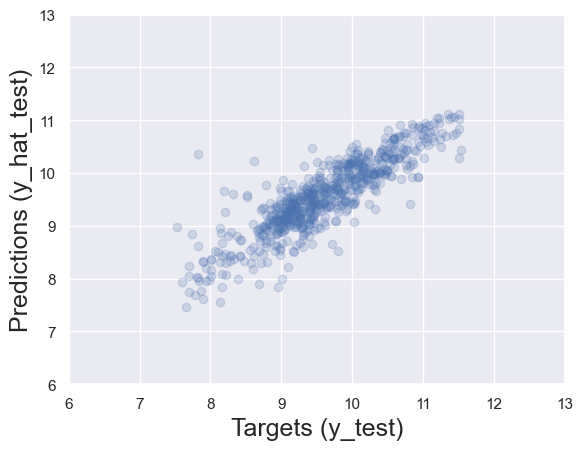

In [100]:
plt.scatter(y_test, y_hat_test, alpha=0.2)
plt.xlabel('Targets (y_test)',size=18)
plt.ylabel('Predictions (y_hat_test)',size=18)
plt.xlim(6,13)
plt.ylim(6,13)
plt.show()

In [102]:
y_hat_test

array([ 9.03483831, 10.47518958,  9.34670371,  8.30450435,  9.25413753,
       10.11113676,  8.87627763,  9.77590977,  9.19687583,  8.30447696,
        9.47118862, 10.15678435, 10.18717762, 10.36203992,  9.11053516,
        9.03355837,  9.20540827,  9.21029164,  9.79982105, 10.24541879,
        9.85678513,  9.51344284,  8.53246867,  9.54877597, 10.39640037,
       10.58111499,  9.33727683,  9.7469053 , 11.12667114,  9.11793332,
        8.93351833, 10.90018272, 10.0046415 ,  9.86789812,  8.46387288,
        9.32552225,  8.63416383,  9.91954406,  8.31504689, 10.17122962,
        9.83884516, 10.16599526,  8.46626329,  8.37898453, 10.03687967,
        9.59048149, 10.29047494, 10.37531838, 11.05409898, 10.1603818 ,
        9.75943931, 10.28807147,  9.65948203,  9.31589912,  7.99884521,
        9.18351783,  9.11452798,  7.94409372,  9.49781617, 10.78706764,
        9.91000267,  9.95707047,  8.52821652,  8.87364743,  9.03468758,
        9.34480067,  9.00921517,  9.85790768,  9.09181298,  9.35

In [103]:
y_test

2679     9.314700
1247    10.542706
84       8.756210
2636     8.716044
938      9.417355
          ...    
439      9.287301
780      9.740910
561     10.896721
1289    10.239960
101     10.126631
Name: log_price, Length: 663, dtype: float64

In [105]:
# To obtaining the actual prices, we take the exponential of the log_price
y_test = y_test.reset_index(drop=True)
df_pf = pd.DataFrame(np.exp(y_hat_test), columns=['Prediction'])
df_pf['Target'] = np.exp(y_test)
df_pf['Residual'] = df_pf['Target'] - df_pf['Prediction']
df_pf['Difference%'] = np.absolute(df_pf['Residual']/df_pf['Target']*100)
df_pf

,Prediction,Target,Residual,Difference%
0,8390.356712,11100.0,2709.643288,24.411201
1,35425.584985,37900.0,2474.415015,6.528800
2,11460.982394,6350.0,-5110.982394,80.487912
3,4042.038218,6100.0,2057.961782,33.737078
4,10447.704056,12300.0,1852.295944,15.059317
...,...,...,...,...
658,12609.261790,10800.0,-1809.261790,16.752424
659,16470.121638,16999.0,528.878362,3.111232
660,33453.526944,53999.0,20545.473056,38.047877
661,12349.041891,28000.0,15650.958109,55.896279
